In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from __future__ import annotations

import os


from mhsxtrapy._boundary import BoundaryData
from mhsxtrapy._field import ExtrapolationResult, extrapolate
from mhsxtrapy.plotting import (find_corners_SDO, find_corners_SolarOrbiter,
                                plot_ddensity_xy, plot_ddensity_z,
                                plot_dpressure_xy, plot_dpressure_z,
                                plot_field_3d)
from mhsxtrapy.types import WhichSolution

#### Example for magnetic field extrapolation from Solar Orbiter/PHI/HRT magnetogram or SDO/HMI magnetogram

Solar Orbiter PHI/HRT magnetogram from 29 March 2023 saved in folder data. Originally downloaded from Solar Orbiter Archive, for details see https://soar.esac.esa.int/soar/.

SDO HMI magnetogram from 13 June 2012 7:31 UT saved in folder EXAMPLE-SDO/data. Originally downloaded from JSOC using SunPy, for details see https://docs.sunpy.org/en/stable/tutorial/acquiring_data/jsoc.html.

Disclaimer: Current problems at JSOC might make downloads using SunPy impossible. Therefore, the data file is provided directly. 

In [ ]:
path_solo = "../data/solo_L2_phi-hrt-blos_20230329T125009_V01.fits"

path_sdo = "../data/hmi_m_45s_2012_06_13_07_31_30_tai_magnetogram.fits"

## Select Soler Orbiter or SDO example using example = "Solar Orbiter" or "SDO"

In [6]:
example = "Solar Orbiter"

##### Determine 2D boundary condition 

SDO/HMI observes full disk magnetograms, such that the obtained line-of-sight magnetic field component needs to be cut to an area around the (active) region, that one aims to investigate. This cutout needs to be close to the disk centre and small enough that neglecting the curvature of the solar surface  is appropriate and the utilisation of Cartesian coordinates justified.

When cutting magnetograms to a smaller size, there is always a trade-off between reducing the size to increase numerical efficiency and keeping enough space around the interesting features to minimise the effects of the boundaries. For a comprehensive comparison of SDO and Solar Orbiter observations see Sinjan et al. (2023) and Vacas et al. (2024).

For Solar Orbiter the pixel number is used for cutting, for SDO the upper and lower longitude and latitude are used.

/var/folders/_n/bcpnhg552nz0sk_18sb4m33r0000gn/T/ipykernel_18089/2086873727.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


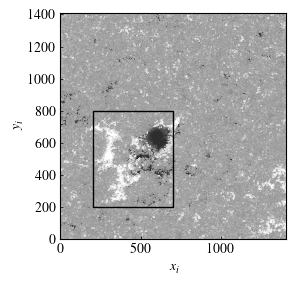

In [7]:
if example == "Solar Orbiter":
    fig, ax = find_corners_SolarOrbiter(path_solo, stx=200, lstx=700, sty=200, lsty=800)
    boundary = BoundaryData.from_fits(example, path_solo, stx=200, lstx=700, sty=200, lsty=800)
elif example == "SDO":
    fig, ax = find_corners_SDO(path_sdo, ulon=-250, llon=-450, ulat=-100, llat=-220)
    boundary = BoundaryData.from_fits(example, path_sdo, ulon=-250, llon=-450, ulat=-100, llat=-220)
    
fig.show()

##### Extrapolate magnetic field

In [ ]:
field = extrapolate(
    boundary,
    alpha=0.0,
    a=0.1,
    which_solution=WhichSolution.NADOL_NEUKIRCH,
    b=1.0,
    z0=2.0,
    deltaz=0.2,
)

In [ ]:
fig, ax = plot_field_3d(
    field,
    view="side",
    footpoints="active-regions",
    pixel_stride_x=10,
    pixel_stride_y=10,
)
fig.show()

fig, ax = plot_dpressure_xy(field, z=4.0)
fig.show()

fig, ax = plot_ddensity_xy(field, z=4.0)
fig.show()

fig, ax = plot_dpressure_z(field)
fig.show()

fig, ax = plot_ddensity_z(field)
fig.show()